In [18]:
import pandas as pd

# Define the path to your text file
file_path = '../Datasets/cancerdesein/risk_rand.txt'

# Read the file with pandas, assuming whitespace as a separator
df = pd.read_csv(file_path, delim_whitespace=True)

# Display the DataFrame
df


C:\Users\zgibio\AppData\Local\Temp\ipykernel_11968\3878290885.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)


,menopaus,agegrp,density,race,Hispanic,bmi,agefirst,nrelbc,brstproc,lastmamm,surgmeno,hrt,invasive,cancer,training,count
0,0,1,1,1,0,1,0,0,0,0,9,9,0,0,1,3
1,0,1,1,1,0,1,0,0,0,9,9,9,0,0,0,2
2,0,1,1,1,0,1,0,0,0,9,9,9,0,0,1,3
3,0,1,1,1,0,1,1,0,0,0,9,9,0,0,1,1
4,0,1,1,1,0,1,1,0,1,9,9,9,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181771,9,4,9,9,9,9,9,9,9,1,9,9,0,0,1,31
181772,9,4,9,9,9,9,9,9,9,9,9,9,0,0,0,154
181773,9,4,9,9,9,9,9,9,9,9,9,9,0,0,1,493
181774,9,4,9,9,9,9,9,9,9,9,9,9,1,1,0,1


In [19]:
from sklearn.model_selection import train_test_split


df["cancer"].value_counts()


cancer
0    175506
1      6270
Name: count, dtype: int64

In [20]:
df.isnull().sum()

menopaus    0
agegrp      0
density     0
race        0
Hispanic    0
bmi         0
agefirst    0
nrelbc      0
brstproc    0
lastmamm    0
surgmeno    0
hrt         0
invasive    0
cancer      0
training    0
count       0
dtype: int64

In [21]:
df.drop('training',axis=1, inplace = True)
df.drop('count',axis=1,inplace = True)

In [22]:
from imblearn.over_sampling import SMOTE
# Split the data into features and target
X = df.drop('cancer', axis=1)
y = df['cancer']
smote = SMOTE(random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print(pd.Series(y_train).value_counts())

cancer
0    140385
1    140385
Name: count, dtype: int64


c:\Users\zgibio\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:53:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


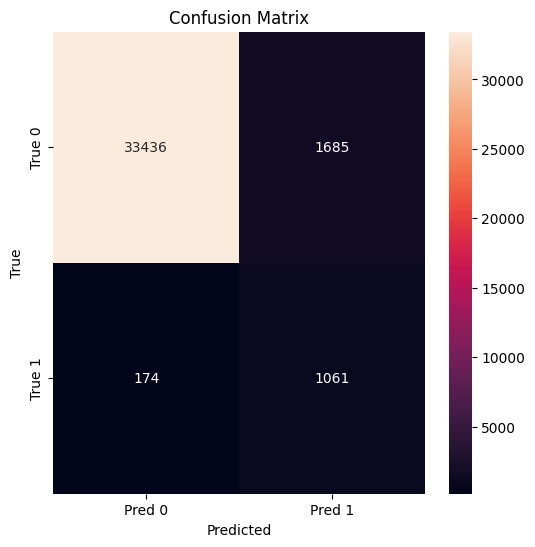

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

neg, pos = y_train.value_counts()
scale = neg / pos
# Train XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False,scale_pos_weight=scale, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_preds = xgb_model.predict(X_test)

# Evaluate
xgb_accuracy = accuracy_score(y_test, xgb_preds)


xgb_accuracy
conf_matrix1 = confusion_matrix(y_test, xgb_preds)

# Plotting confusion matrix as a heatmap for better visualization
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix1, annot=True, fmt='g', xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [24]:
df_test= pd.read_csv("../Datasets/cancerdesein/test.txt", delim_whitespace=True)

C:\Users\zgibio\AppData\Local\Temp\ipykernel_11968\2879333417.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_test= pd.read_csv("../Datasets/cancerdesein/test.txt", delim_whitespace=True)


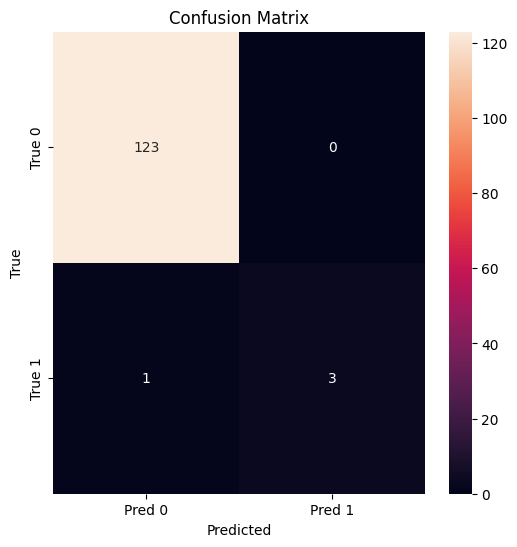

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df_test.drop('training',axis=1, inplace = True)
df_test.drop('count',axis=1,inplace = True)

# Step 1: Separate the features and target from df_test
X_man = df_test.drop(columns=["cancer"])  # features
y_man = df_test["cancer"]  # target label

# Step 2: Make predictions using the trained model
y_pred = xgb_model.predict(X_man)


conf_matrixtest = confusion_matrix(y_man, y_pred)

# Plotting confusion matrix as a heatmap for better visualization
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrixtest, annot=True, fmt='g', xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Random Forest Accuracy: 0.9599790956100781
Random Forest Confusion Matrix:


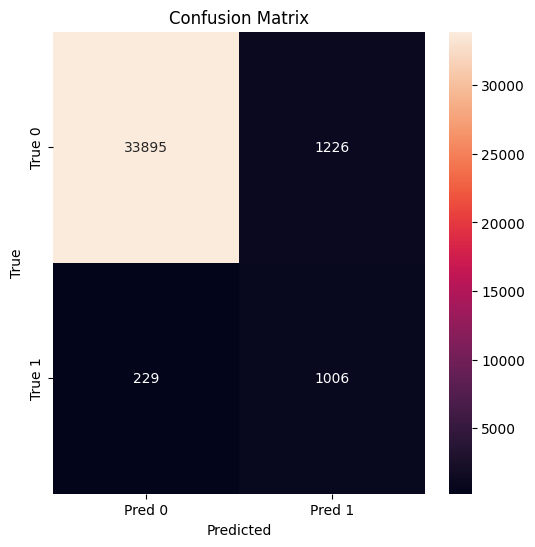

In [26]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_preds = rf_model.predict(X_test)

# Evaluate
rf_accuracy = accuracy_score(y_test, rf_preds)


print(f"Random Forest Accuracy: {rf_accuracy}")
print("Random Forest Confusion Matrix:")
# Step 4: Confusion Matrix
conf_matrix = confusion_matrix(y_test, rf_preds)

# Plotting confusion matrix as a heatmap for better visualization
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [27]:
import pickle
with open('breastcancer.pkl', 'wb') as file:
  pickle.dump(rf_model, file)